In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

data = pd.read_csv("A2data.tsv", sep="\t")
data = data.iloc[:, 1:]
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
model = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model,X,y,cv=cv,scoring='neg_root_mean_squared_error')
rmse = -scores

print("Baseline Model: Linear Regression")
print("RMSE for each fold:", rmse)
print("Mean RMSE:", rmse.mean())
print("Std RMSE:", rmse.std())

Baseline Model: Linear Regression
RMSE for each fold: [1.47526526 1.888405   1.8315792  1.94119887 2.81917886]
Mean RMSE: 1.9911254390867021
Std RMSE: 0.44503558269735577


Task 1, Linear Regression was used as the baseline model because it is the simplest regression method covered in the course and can be applied directly to the raw dataset. The first column, InstanceID, was removed since it only contains identifiers and does not contribute to prediction.

A 5-fold cross-validation method was used because the dataset has only 48 samples. This allows each model to be tested several times while still keeping enough data for training in each fold.

The baseline model produced an average RMSE of 1.99 ± 0.45.

In [14]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_scores = -cross_val_score(tree_model,X,y,cv=cv,scoring="neg_root_mean_squared_error")
tree_mean_rmse = tree_scores.mean()
tree_std_rmse = tree_scores.std()

print("Decision Tree Mean RMSE:", tree_mean_rmse)
print("Decision Tree Std RMSE:", tree_std_rmse)

Decision Tree Mean RMSE: 0.8395067573017669
Decision Tree Std RMSE: 0.1410659407220125


Decision Tree Regression was chosen as the first alternative model because tree-based methods were covered in class and can handle non-linear patterns better than linear models.

Using the same 5-fold cross-validation setting, the model achieved an average RMSE of 0.84 ± 0.14, which is clearly lower than the baseline result.

This shows that a tree-based model fits this dataset better than a simple linear regression model.

In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_scores = -cross_val_score(rf_model,X,y,cv=cv,scoring="neg_root_mean_squared_error")
rf_mean_rmse = rf_scores.mean()
rf_std_rmse = rf_scores.std()

print("Random Forest Mean RMSE:", rf_mean_rmse)
print("Random Forest Std RMSE:", rf_std_rmse)

Random Forest Mean RMSE: 0.6379820082501548
Random Forest Std RMSE: 0.14295840340691737


Random Forest Regression was selected as the second alternative model because it combines multiple decision trees and usually gives more stable predictions.

Its average RMSE was 0.64 ± 0.14, which was the best result among all tested models.

This means Random Forest performed best for this dataset.

/var/folders/tc/v771vpvx4msb3jcj82ncmsrm0000gn/T/ipykernel_12704/3651594151.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([baseline_scores, tree_scores, rf_scores],labels=["Linear Regression", "Decision Tree", "Random Forest"])


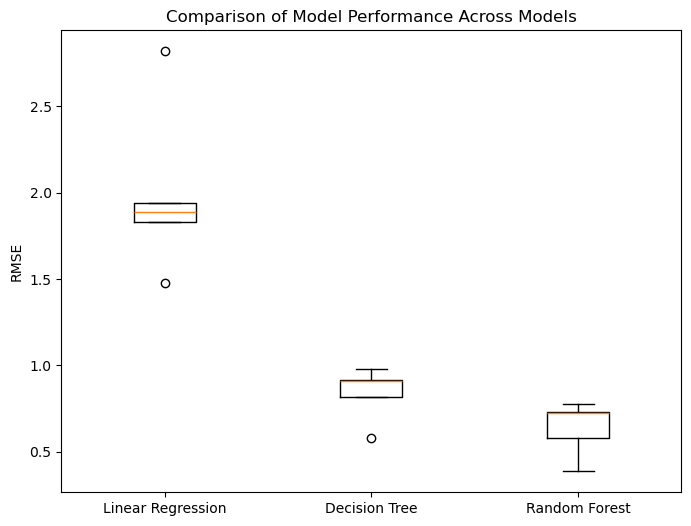

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.boxplot([baseline_scores, tree_scores, rf_scores],labels=["Linear Regression", "Decision Tree", "Random Forest"])
plt.ylabel("RMSE")
plt.title("Comparison of Model Performance Across Models")
plt.show()

Task 3 compares the performance of all regression models using RMSE values obtained from 5-fold cross-validation. A boxplot is included to visualize the variation in prediction error across folds for each model.

The results show that Linear Regression produced the highest RMSE, while Decision Tree substantially reduced prediction error. Random Forest achieved the lowest average RMSE among all tested models.

These results indicate that tree-based methods are more suitable for this dataset than the baseline linear model, with Random Forest providing the strongest overall performance.